In [3]:
import pandas as pd

customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")
products = pd.read_csv("../data/raw/olist_products_dataset.csv")
translation = pd.read_csv("../data/raw/product_category_name_translation.csv")

print("Files Loaded Successfully")

Files Loaded Successfully


In [4]:
products = products.merge(
    translation,
    on="product_category_name",
    how="left"
)

In [5]:
df = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

In [6]:
df = df.merge(
    items,
    on="order_id",
    how="left"
)

In [7]:
df = df.merge(
    payments,
    on="order_id",
    how="left"
)

In [8]:
df = df.merge(
    products,
    on="product_id",
    how="left"
)

In [9]:
df["revenue"] = df["price"] + df["freight_value"]

In [10]:
df["order_purchase_timestamp"] = pd.to_datetime(
    df["order_purchase_timestamp"]
)

In [11]:
df["Year"] = df["order_purchase_timestamp"].dt.year

df["Month"] = df["order_purchase_timestamp"].dt.month

df["Month_Name"] = df["order_purchase_timestamp"].dt.strftime("%b")

In [12]:
df = df[df["revenue"].notna()]

In [16]:
df.to_csv(
    "../data/processed/olist_cleaned.csv",
    index=False
)

print(df.shape)
print("Dataset Saved")

(117604, 35)
Dataset Saved


In [18]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/processed/olist_cleaned.csv"
)

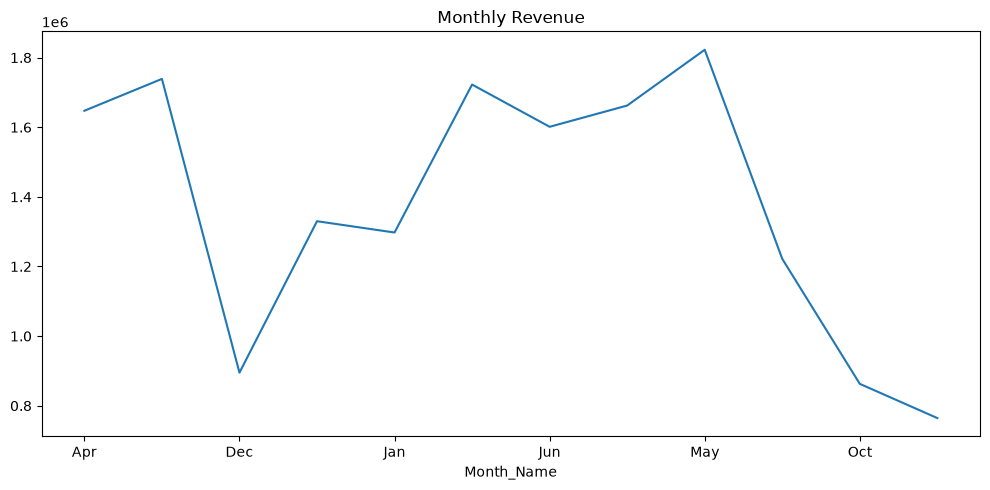

In [20]:
monthly = df.groupby(
    "Month_Name"
)["revenue"].sum()

monthly.plot(
    kind="line",
    figsize=(10,5)
)

plt.title("Monthly Revenue")
plt.tight_layout()

plt.savefig(
    "../screenshots/monthly_revenue.png"
)

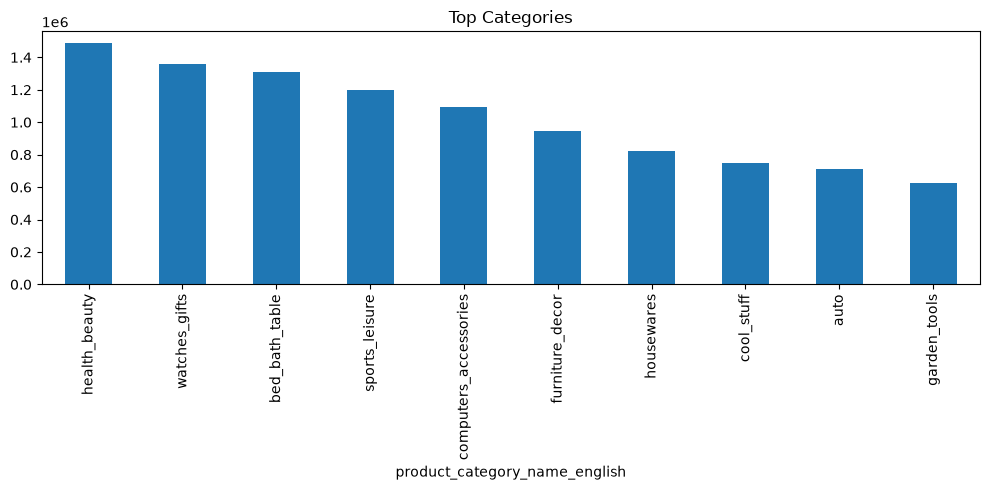

In [21]:
category = df.groupby(
    "product_category_name_english"
)["revenue"].sum()

category = category.sort_values(
    ascending=False
).head(10)

category.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top Categories")

plt.tight_layout()

plt.savefig(
    "../screenshots/top_categories.png"
)

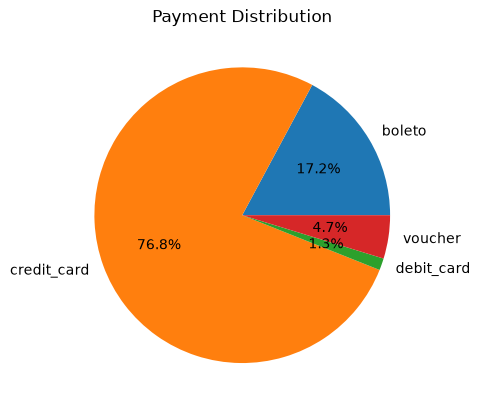

In [22]:
payment = df.groupby(
    "payment_type"
)["revenue"].sum()

payment.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Payment Distribution")

plt.savefig(
    "../screenshots/payment_distribution.png"
)

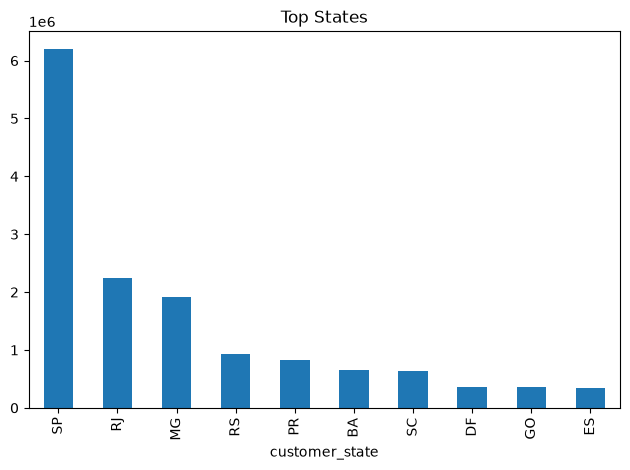

In [23]:
state = df.groupby(
    "customer_state"
)["revenue"].sum()

state = state.sort_values(
    ascending=False
).head(10)

state.plot(
    kind="bar"
)

plt.title("Top States")

plt.tight_layout()

plt.savefig(
    "../screenshots/top_states.png"
)